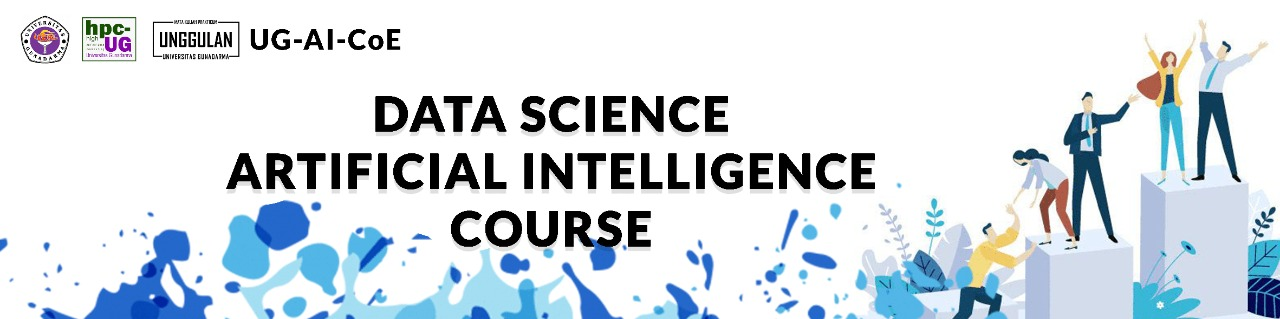

# Ship Performance Clustering & Fleet Segmentation System
---


Dataset diperoleh melalui kaggle, link: https://www.kaggle.com/datasets/jeleeladekunlefijabi/ship-performance-clustering-dataset/data

## 1. Business Understanding
---

### 1.1 Latar Belakang Masalah

Industri transportasi laut dan pelayaran menghadapi tantangan dalam menyeimbangkan antara konsumsi bahan bakar, biaya operasinal, waktu sandar, dan keandalan armada. Setiap kapal memiliki karakteristik unik yang mempengaruhi hal di atas. Sehingga segmentasi diperlukan dalam mengidentifikasi kapal, mengalokasikan jadwal perawatan, dan mengoptimalkan keuntungan atau profit setiap pelayaran.

### 1.2 Tujuan Bisnis
- Melakukan segmentasi profil kinerja kapal ke dalam cluster untuk mempermudah pengambilan keputusan
- Menghasilkan strategi operasional untuk efisiensi bahan bakar, dan jadwal perawatan kapal

### 1.3 Tujuan Data Mining

- Mengeksplorasi struktur dan hubungan antar atribut melalui Exploratory Data Analysis (EDA)
- Melakukan Data Preparation untuk menangani missing value, feature engineering, dan standardization
- Menerapkan algoritma Unsupervised Learning berbasis K-Means Clustering dan Agglomerative Hierarchical Clustering
- Menentukan jumlah cluster optimal (k) menggunakan Elbow Method dan Silhouette Analysis
- Menguji validitas cluster dengan metrik evaluasi

### 1.4 Kriteria Keberhasilan
- Kriteria Teknis: Cluster memiliki nilai Silhouette Score yang positive dan Davies-Bouldin Index yang rendah
- Kriteria Bisnis: Setiap cluster memiliki profil karakteristik yang dapat diinterpretasikan dengan jelas

### 1.5 Alasan Pemilihan Dataset
Adapun alasan mengapa dataset ship-performance-clustering ini layak untuk digunakan adalah sebagai berikut.
1. Dataset memiliki jumlah observasi yang cukup (2736 observasi)
2. Dataset tidak memiliki label yang harus diprediksi, sehingga cocok untuk unsupervised learning
3. Dataset memiliki kombinasi fitur numerik dan kategorikal, sehingga memungkinkan karakteristik tidak hanya dianalisis dari sisi angka, tetapi juga karakteristik kapal dan kondisi operasionalnya.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage


## 2. Data Understanding
---

In [2]:
df_raw = pd.read_csv("data/Ship_Performance_Dataset.csv")
df_raw.head()

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581


In [3]:
df_raw.shape

(2736, 18)

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2736 non-null   str    
 1   Ship_Type                2600 non-null   str    
 2   Route_Type               2600 non-null   str    
 3   Engine_Type              2600 non-null   str    
 4   Maintenance_Status       2600 non-null   str    
 5   Speed_Over_Ground_knots  2736 non-null   float64
 6   Engine_Power_kW          2736 non-null   float64
 7   Distance_Traveled_nm     2736 non-null   float64
 8   Draft_meters             2736 non-null   float64
 9   Weather_Condition        2600 non-null   str    
 10  Cargo_Weight_tons        2736 non-null   float64
 11  Operational_Cost_USD     2736 non-null   float64
 12  Revenue_per_Voyage_USD   2736 non-null   float64
 13  Turnaround_Time_hours    2736 non-null   float64
 14  Efficiency_nm_per_kWh    2736 non-n

In [5]:
df_raw.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Speed_Over_Ground_knots,2736.0,17.60,4.31,10.01,13.93,17.71,21.28,25.00
Engine_Power_kW,2736.0,1757.61,717.00,501.03,1148.10,1757.49,2382.59,2998.73
Distance_Traveled_nm,2736.0,1036.41,568.63,50.43,548.51,1037.82,1540.93,1998.34
Draft_meters,2736.0,9.93,2.88,5.00,7.44,9.92,12.41,14.99
Cargo_Weight_tons,2736.0,1032.57,558.70,50.23,553.98,1043.21,1527.72,1999.13
Operational_Cost_USD,2736.0,255143.34,140890.48,10092.31,131293.38,257157.65,381796.93,499734.87
Revenue_per_Voyage_USD,2736.0,521362.06,271211.63,50351.81,290346.39,520176.93,750072.79,999916.70
Turnaround_Time_hours,2736.0,41.75,17.63,12.02,26.17,41.59,57.36,71.97
Efficiency_nm_per_kWh,2736.0,0.80,0.40,0.10,0.46,0.79,1.15,1.50
Seasonal_Impact_Score,2736.0,1.00,0.29,0.50,0.76,1.01,1.25,1.50


In [6]:
df_raw.describe(include='object').T

,count,unique,top,freq
Date,2736,57,2023-06-04,48
Ship_Type,2600,4,Bulk Carrier,669
Route_Type,2600,4,Long-haul,686
Engine_Type,2600,3,Diesel,892
Maintenance_Status,2600,3,Good,873
Weather_Condition,2600,3,Calm,893


In [7]:
missing_vals = df_raw.isnull().sum()
missing_pct = (missing_vals / len(df_raw)) * 100
missing_df = pd.DataFrame({'Total Missing': missing_vals, 'Persentase (%)': missing_pct.round(2)})
missing_df = missing_df[missing_df['Total Missing'] > 0]
display(missing_df)

,Total Missing,Persentase (%)
Ship_Type,136,4.97
Route_Type,136,4.97
Engine_Type,136,4.97
Maintenance_Status,136,4.97
Weather_Condition,136,4.97


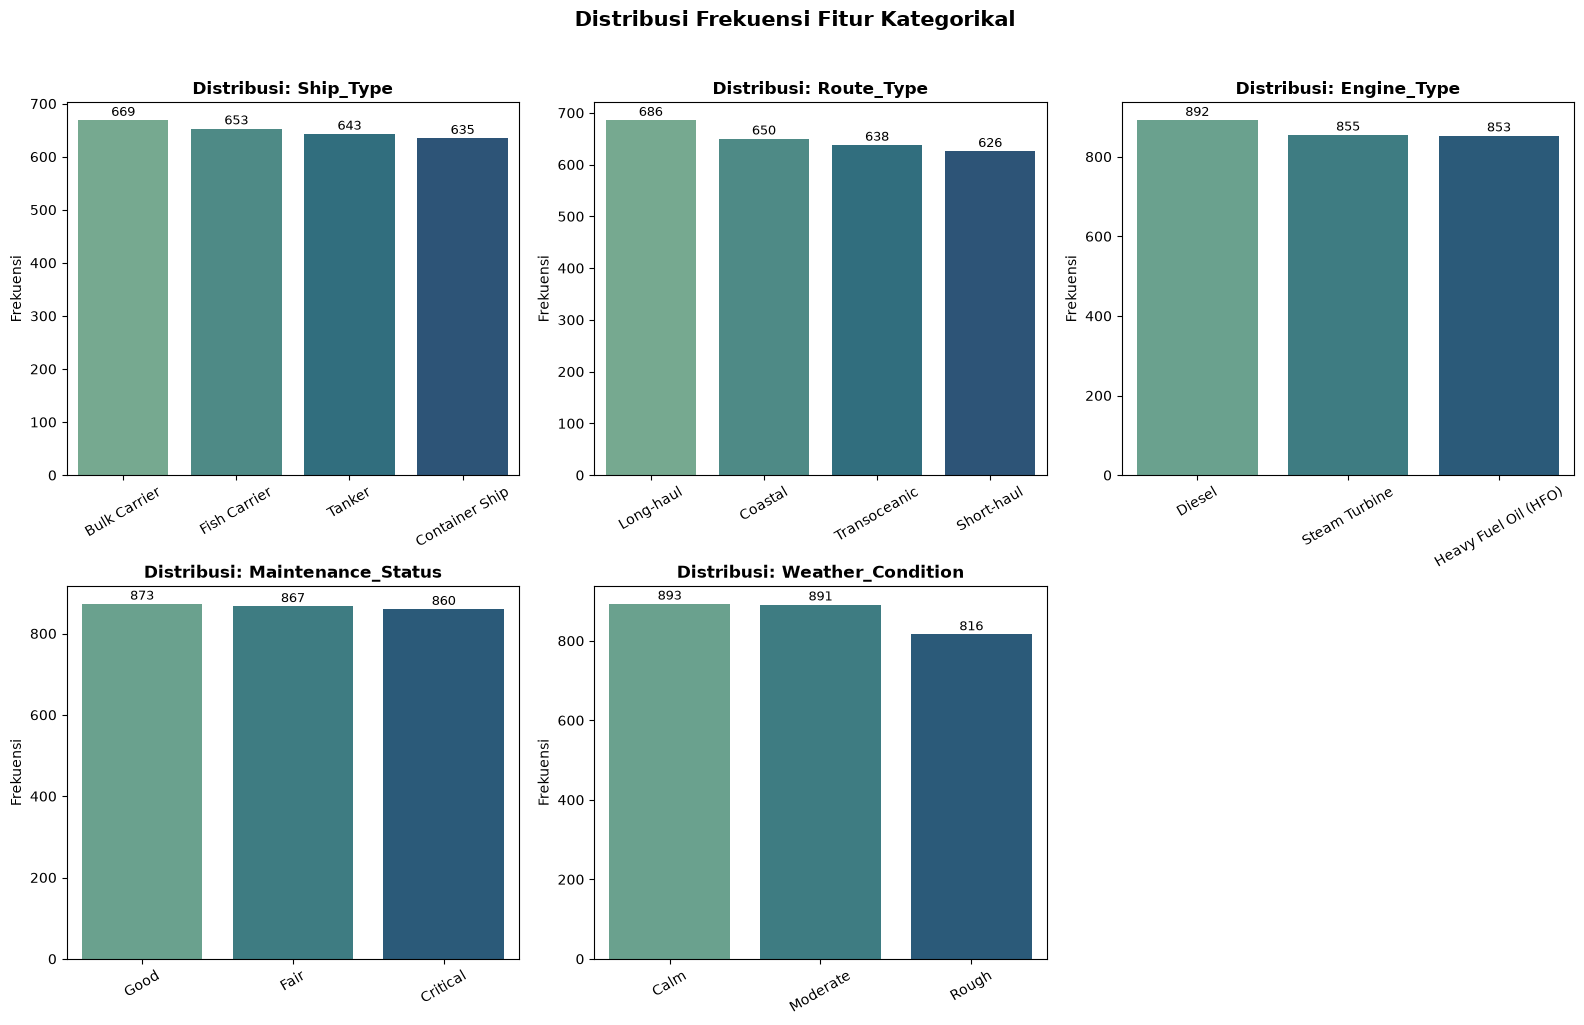

In [8]:
# Visualisasi Distribusi Variabel Kategorikal
cat_cols = ['Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status', 'Weather_Condition']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_raw[col].value_counts(dropna=False)
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[i], palette='crest')
    axes[i].set_title(f'Distribusi: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()),
                         ha='center', va='baseline', fontsize=9, xytext=(0, 3), textcoords='offset points')

axes[5].axis('off')
plt.suptitle('Distribusi Frekuensi Fitur Kategorikal', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

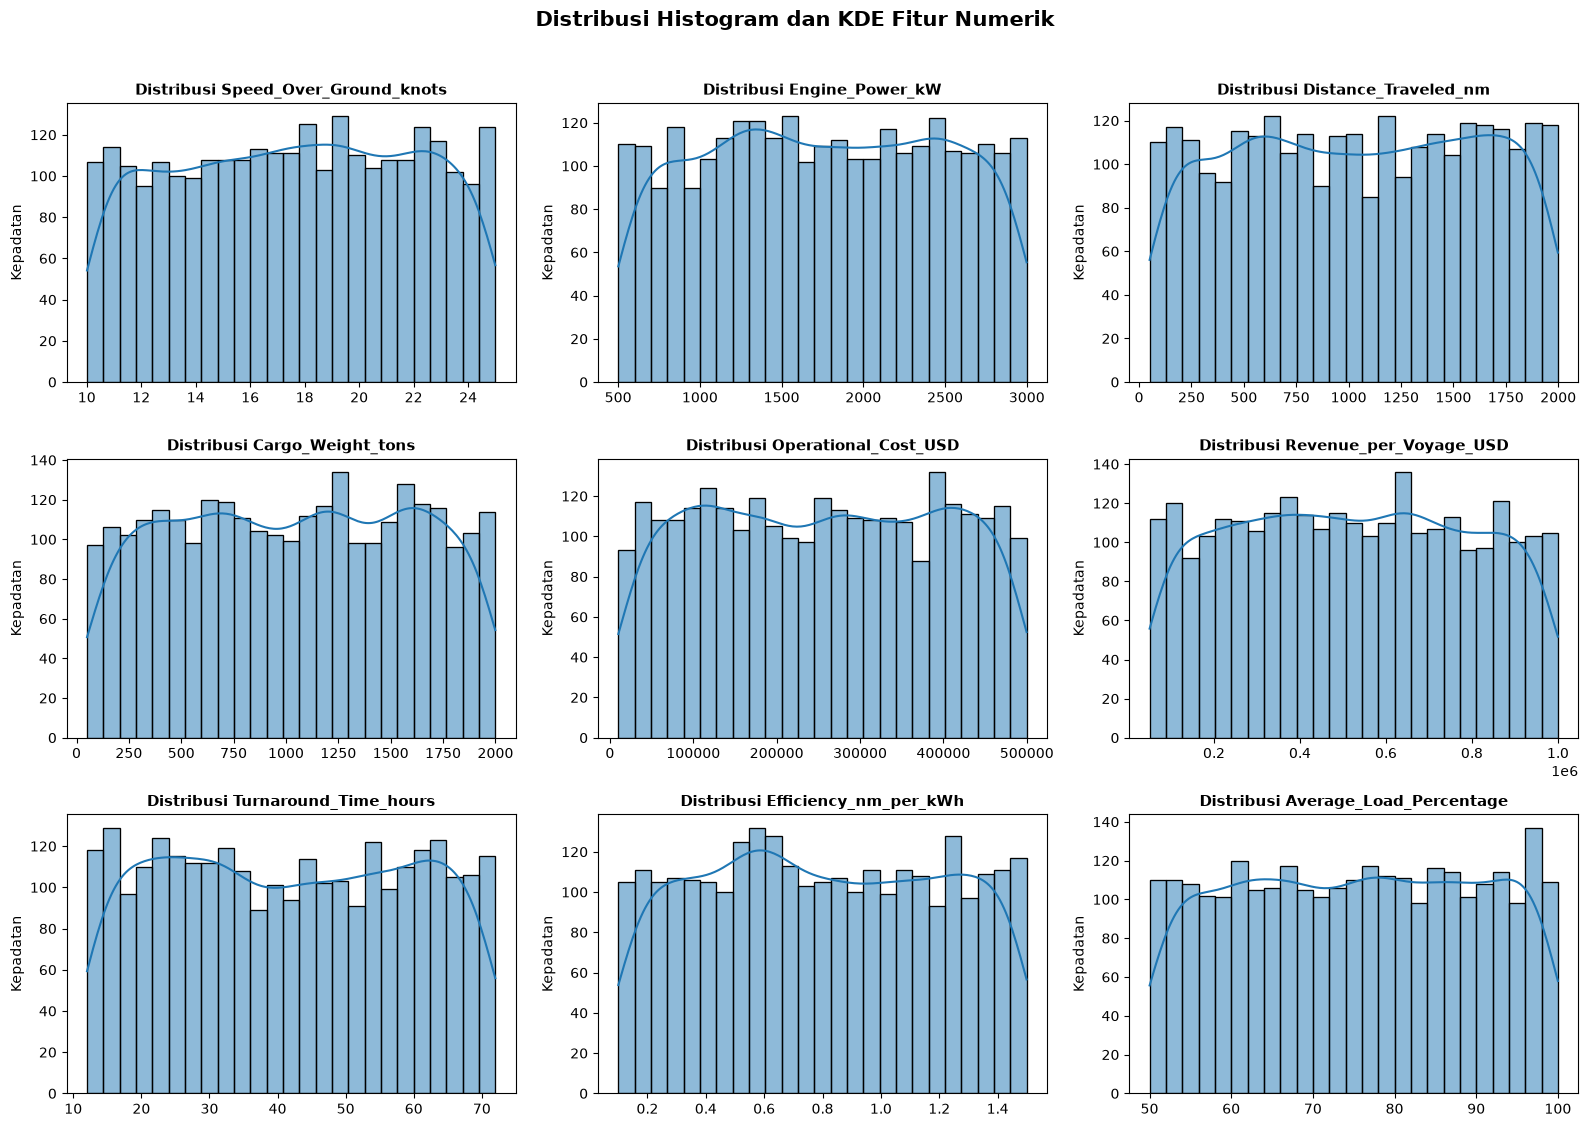

In [9]:
# Visualisasi Distribusi Fitur Numerik
key_num_cols = [
    'Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm',
    'Cargo_Weight_tons', 'Operational_Cost_USD', 'Revenue_per_Voyage_USD',
    'Turnaround_Time_hours', 'Efficiency_nm_per_kWh', 'Average_Load_Percentage'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    sns.histplot(df_raw[col], kde=True, ax=axes[i], color='#1f77b4', bins=25)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Kepadatan')

plt.suptitle('Distribusi Histogram dan KDE Fitur Numerik', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

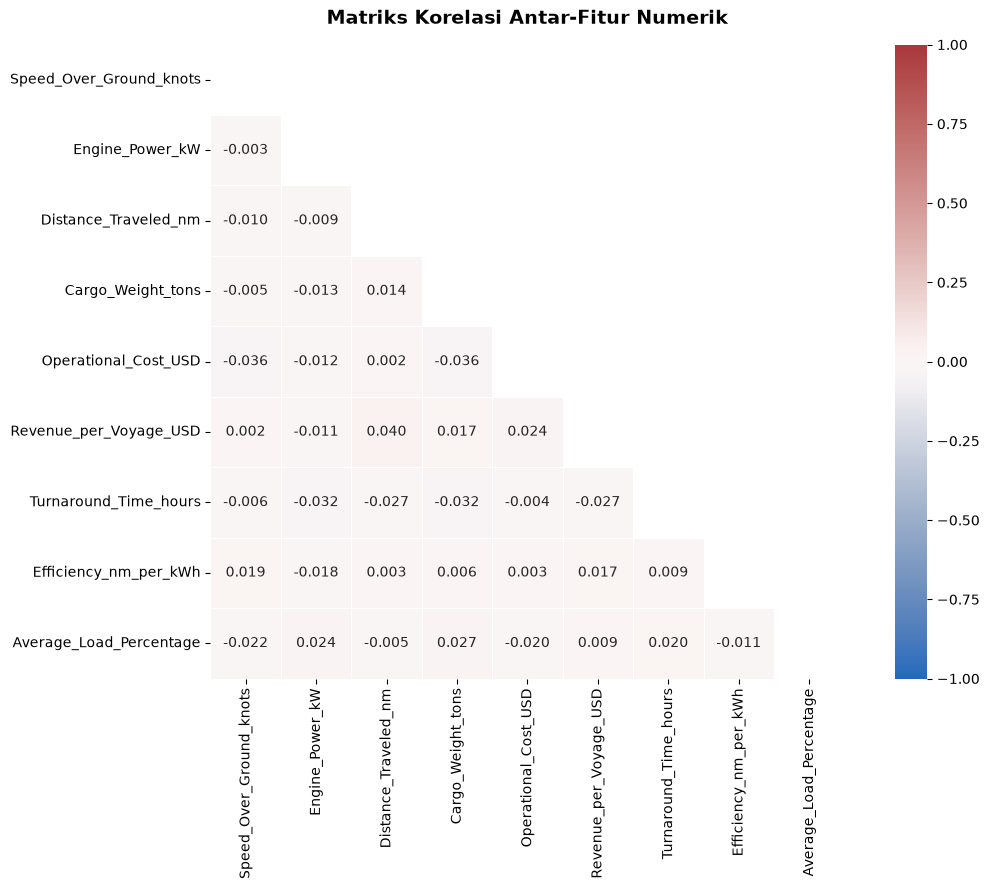

In [10]:
# Visualisasi Matriks Korelasi (Pearson Correlation)
plt.figure(figsize=(12, 9))
corr_matrix = df_raw[key_num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='vlag', vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Matriks Korelasi Antar-Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 3. Data Preparation
---

### 3.1 Imputasi Data
Karena data dengan nilai hilang terdapat pada fitur kategorikal, imputasi dilakukan pada fitur kategorikal dengan nilai modus.


In [11]:
df_clean = df_raw.copy()

# Imputasi modus pada kolom kategorikal
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

print(f"Total missing values setelah imputasi: {df_clean.isnull().sum().sum()}")

Total missing values setelah imputasi: 0


### 3.2 Feature Engineering
Pada tahap ini, dilakukan pembuatan atribut rasio operasional dan finansial agar relevan dengan analisis kinerja armada kapal:
- Profit_USD = Revenue_per_Voyage_USD - Operational_Cost_USD
- Cost_per_nm = Operational_Cost_USD / Distance_Traveled_nm (Biaya per mil laut)
- Profit_per_nm = Profit_USD / Distance_Traveled_nm (Profit per mil laut)
- Revenue_per_nm = Revenue_per_Voyage_USD / Distance_Traveled_nm (Pendapatan per mil laut)
- Profit_Margin_Pct = (Profit_USD / Revenue_per_Voyage_USD) * 100
- Cargo_Utilization = Cargo_Weight_tons * (Average_Load_Percentage / 100.0)
- Power_per_Speed = Engine_Power_kW / Speed_Over_Ground_knots


In [12]:
df_clean['Profit_USD'] = df_clean['Revenue_per_Voyage_USD'] - df_clean['Operational_Cost_USD']
df_clean['Cost_per_nm'] = df_clean['Operational_Cost_USD'] / df_clean['Distance_Traveled_nm']
df_clean['Revenue_per_nm'] = df_clean['Revenue_per_Voyage_USD'] / df_clean['Distance_Traveled_nm']
df_clean['Profit_per_nm'] = df_clean['Profit_USD'] / df_clean['Distance_Traveled_nm']
df_clean['Profit_Margin_Pct'] = (df_clean['Profit_USD'] / df_clean['Revenue_per_Voyage_USD']) * 100
df_clean['Cargo_Utilization'] = df_clean['Cargo_Weight_tons'] * (df_clean['Average_Load_Percentage'] / 100.0)
df_clean['Power_per_Speed'] = df_clean['Engine_Power_kW'] / df_clean['Speed_Over_Ground_knots']

df_clean['Date'] = pd.to_datetime(df_clean['Date'])

display(df_clean[['Profit_USD', 'Cost_per_nm', 'Profit_per_nm', 'Profit_Margin_Pct', 'Cargo_Utilization']].describe().round(2))


,Profit_USD,Cost_per_nm,Profit_per_nm,Profit_Margin_Pct,Cargo_Utilization
count,2736.00,2736.00,2736.00,2736.00,2736.00
mean,266218.72,486.05,477.38,20.20,778.86
std,302625.26,802.14,1083.55,101.78,458.44
min,-444584.05,5.55,-4989.24,-865.00,26.94
25%,40885.28,130.68,41.91,13.57,391.60
50%,262716.14,244.13,261.69,50.42,742.38
75%,492215.84,475.25,548.32,74.57,1121.12
max,977168.39,9002.81,14756.96,98.73,1981.66


### 3.3 Feature Selection
Pada tahap ini, dilakukan pemilihan fitur yang akan digunakan untuk Segmentasi atau Clustering.


In [13]:
# Fitur Teroptimasi: Profitability, Energy Efficiency, Cost Rate, and Cargo Utilization
clustering_features = [
    'Profit_Margin_Pct',
    'Efficiency_nm_per_kWh',
    'Cost_per_nm',
    'Cargo_Utilization'
]

X = df_clean[clustering_features].copy()
display(X.head())


,Profit_Margin_Pct,Efficiency_nm_per_kWh,Cost_per_nm,Cargo_Utilization
0,-65.592078,1.455179,469.310200,1836.956365
1,45.303608,0.290361,455.817263,152.481119
2,-13.838087,0.499595,680.772509,171.307844
3,-198.509995,0.702906,231.935022,1150.039617
4,57.445756,1.331343,199.074328,208.498444


### 3.4 Standarisasi Fitur
Pada tahap ini, dilakukan standarisasi fitur (menggunakan RobustScaler) agar seluruh fitur memiliki skala yang seragam dan tidak terdistorsi oleh nilai ekstrem (outliers) pada algoritma clustering.


In [14]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

display(X_scaled_df.describe().round(3).loc[['mean', 'std', 'min', '50%', 'max']])


,Profit_Margin_Pct,Efficiency_nm_per_kWh,Cost_per_nm,Cargo_Utilization
mean,-0.495,0.013,0.702,0.050
std,1.669,0.590,2.328,0.628
min,-15.007,-1.009,-0.692,-0.981
50%,0.000,0.000,0.000,-0.000
max,0.792,1.037,25.419,1.699


### 3.5 Reduksi Dimensi dengan PCA
Pada tahap ini, dilakukan Principal Component Analysis (PCA) agar dimensi fitur dapat direduksi menjadi komponen utama yang menangkap sebagian besar varians data, mempermudah visualisasi sebaran klaster dalam ruang 2D/3D, serta mengurangi multikolinearitas.

In [15]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_exp_var = pca.explained_variance_ratio_
print("Varians yang dijelaskan oleh masing-masing Principal Component:")
for i, var in enumerate(pca_exp_var):
    print(f"  PC{i+1}: {var*100:.2f}% (Kumulatif: {np.sum(pca_exp_var[:i+1])*100:.2f}%)")

Varians yang dijelaskan oleh masing-masing Principal Component:
  PC1: 62.23% (Kumulatif: 62.23%)
  PC2: 29.47% (Kumulatif: 91.71%)
  PC3: 4.40% (Kumulatif: 96.11%)


## 4. Modeling
---

In [16]:
# 4.1 Penentuan Nilai k Optimal (Elbow Method & Silhouette Score)
k_range = range(2, 9)
inertias = []
sil_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

# Ringkasan Evaluasi Parameter k
k_eval_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia (WCSS)': [round(x, 2) for x in inertias],
    'Silhouette Score': [round(x, 4) for x in sil_scores],
    'Davies-Bouldin Index': [round(x, 4) for x in db_scores],
    'Calinski-Harabasz': [round(x, 2) for x in ch_scores]
})
display(k_eval_df)

,k,Inertia (WCSS),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz
0,2,14518.05,0.7069,0.6996,1873.84
1,3,9967.87,0.5996,0.7496,1987.89
2,4,7566.00,0.5764,0.7064,2034.43
3,5,6371.34,0.4209,0.8577,1939.28
4,6,5575.96,0.3844,0.8958,1849.99
5,7,5059.93,0.2414,1.0655,1744.62
6,8,4527.48,0.2478,1.0507,1716.49


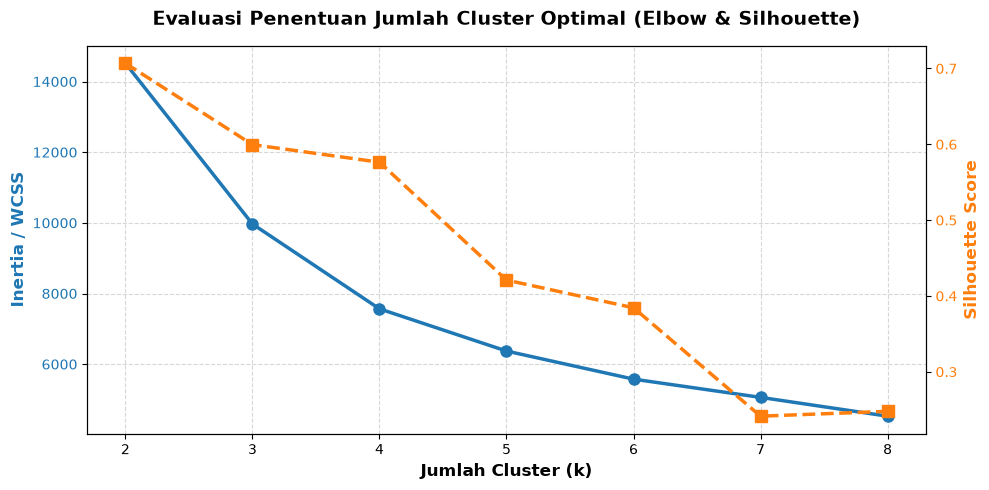

In [17]:
# Visualisasi Elbow Method dan Silhouette Score
fig, ax1 = plt.subplots(figsize=(10, 5))

color = '#1f77b4'
ax1.set_xlabel('Jumlah Cluster (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inertia / WCSS', color=color, fontsize=12, fontweight='bold')
ax1.plot(k_range, inertias, marker='o', linewidth=2.5, markersize=8, color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12, fontweight='bold')
ax2.plot(k_range, sil_scores, marker='s', linewidth=2.5, markersize=8, color=color, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Penentuan Jumlah Cluster Optimal (Elbow & Silhouette)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

In [18]:
# 4.2 Penerapan K-Means Clustering dengan k Optimal (k = 3)
OPTIMAL_K = 3
kmeans_model = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

# Tambahkan label cluster ke dataset
df_clean['Cluster_KMeans'] = kmeans_labels
df_clean['Cluster_Name'] = df_clean['Cluster_KMeans'].map({
    0: 'Cluster 0: Moderate Fleet',
    1: 'Cluster 1: High Efficiency & Profit',
    2: 'Cluster 2: Heavy Load & High Cost'
})

print(f"Distribusi anggota cluster K-Means (k={OPTIMAL_K}):")
display(df_clean['Cluster_KMeans'].value_counts().sort_index())

Distribusi anggota cluster K-Means (k=3):


Cluster_KMeans
0    2365
1     147
2     224
Name: count, dtype: int64

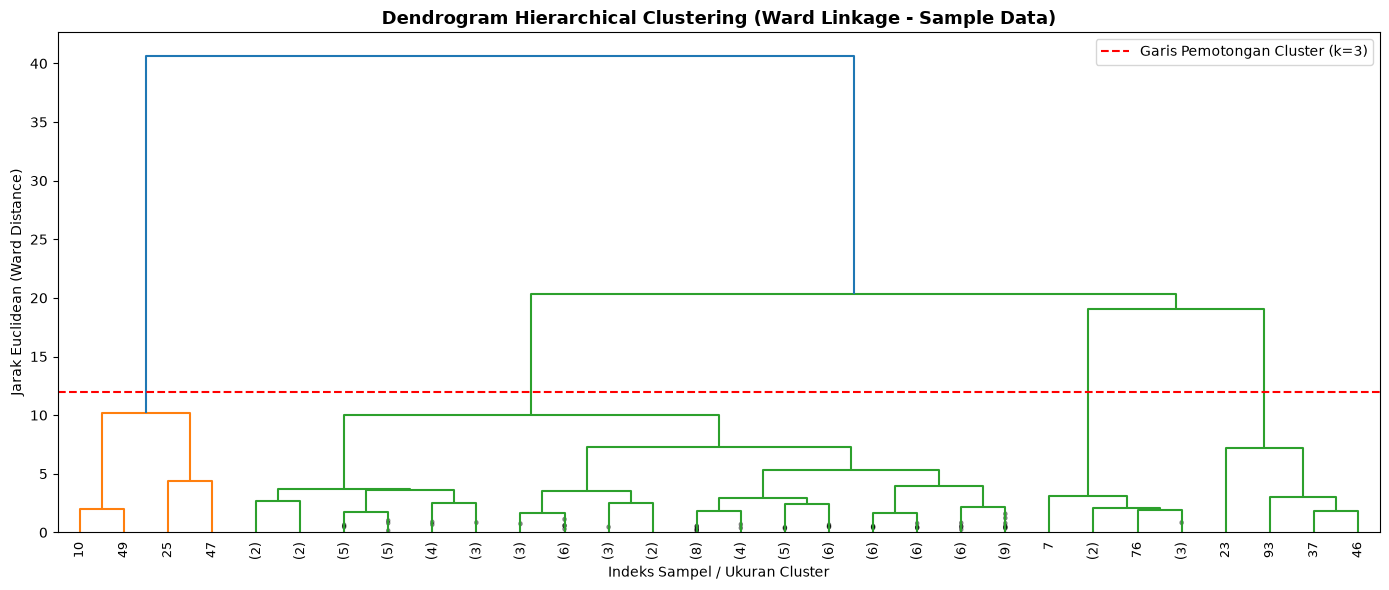

In [19]:
# 4.3 Penerapan Hierarchical Clustering (Agglomerative)
# Visualisasi Dendrogram (Sampel 100 data untuk kejelasan visual)
plt.figure(figsize=(14, 6))
sample_indices = np.random.RandomState(42).choice(len(X_scaled), size=100, replace=False)
linkage_matrix = linkage(X_scaled[sample_indices], method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage - Sample Data)', fontsize=13, fontweight='bold')
plt.xlabel('Indeks Sampel / Ukuran Cluster')
plt.ylabel('Jarak Euclidean (Ward Distance)')
plt.axhline(y=12, color='r', linestyle='--', label='Garis Pemotongan Cluster (k=3)')
plt.legend()
plt.tight_layout()
plt.show()

# Model Agglomerative Clustering
agg_model = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled)
df_clean['Cluster_Hierarchical'] = agg_labels

## 5. Evaluation
---

In [20]:
# 5.1 Perbandingan Metrik Evaluasi Kuantitatif
eval_comparison = pd.DataFrame({
    'Algoritma': ['K-Means Clustering', 'Agglomerative Hierarchical'],
    'Silhouette Score': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, agg_labels)
    ],
    'Davies-Bouldin Index': [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, agg_labels)
    ],
    'Calinski-Harabasz Index': [
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, agg_labels)
    ]
})

print("Perbandingan Metrik Evaluasi Clustering (k=3):")
display(eval_comparison.round(4))

Perbandingan Metrik Evaluasi Clustering (k=3):


,Algoritma,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means Clustering,0.5996,0.7496,1987.8936
1,Agglomerative Hierarchical,0.6574,0.7205,1602.7093


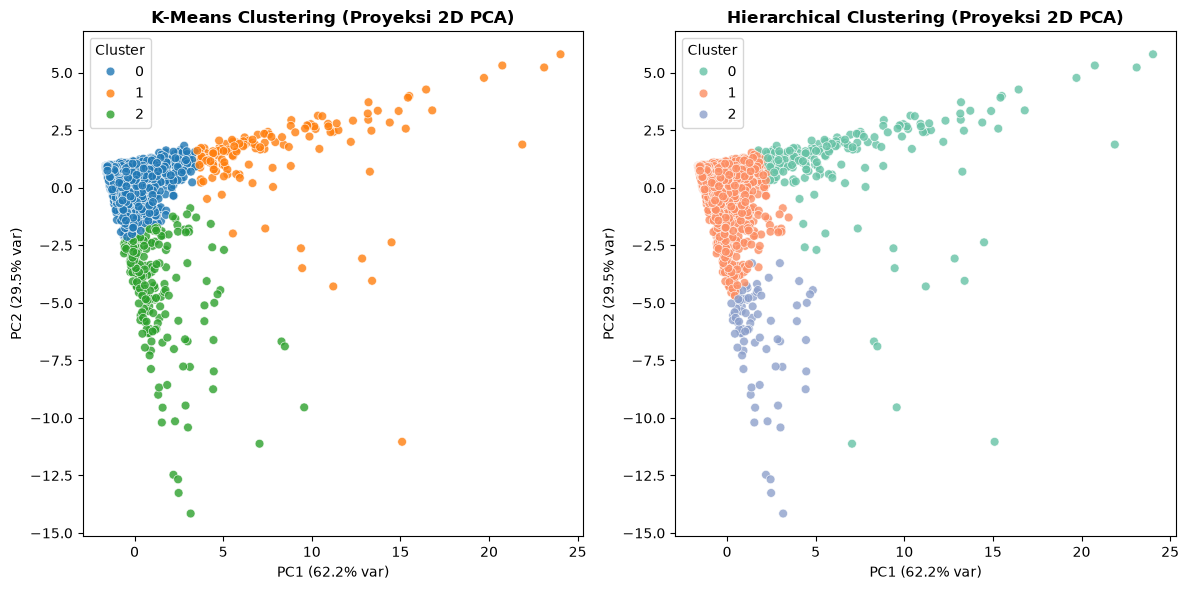

In [21]:
# 5.2 Visualisasi 2D Proyeksi PCA
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['Cluster_KMeans'], palette='tab10', alpha=0.8, s=40)
plt.title('K-Means Clustering (Proyeksi 2D PCA)', fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({pca_exp_var[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca_exp_var[1]*100:.1f}% var)')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['Cluster_Hierarchical'], palette='Set2', alpha=0.8, s=40)
plt.title('Hierarchical Clustering (Proyeksi 2D PCA)', fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({pca_exp_var[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca_exp_var[1]*100:.1f}% var)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

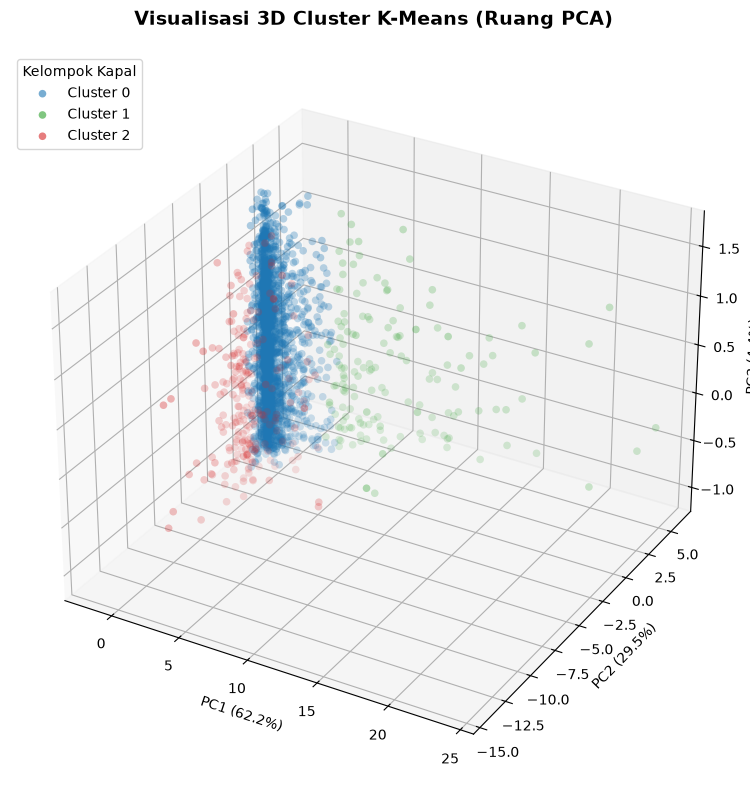

In [22]:
# 5.3 Visualisasi 3D Proyeksi PCA
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#1f77b4', '#2ca02c', '#d62728']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for c, col, name in zip(range(OPTIMAL_K), colors, cluster_names):
    idx = df_clean['Cluster_KMeans'] == c
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2], c=col, label=name, alpha=0.6, s=30, edgecolors='none')

ax.set_title('Visualisasi 3D Cluster K-Means (Ruang PCA)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel(f'PC1 ({pca_exp_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_exp_var[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_exp_var[2]*100:.1f}%)')
ax.legend(title='Kelompok Kapal', loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
# 5.4 Analisis Profil Karakteristik Cluster (Cluster Centroid Profiling)
profile_cols = list(dict.fromkeys(clustering_features + ["Distance_Traveled_nm", "Turnaround_Time_hours"]))
cluster_summary = df_clean.groupby("Cluster_KMeans")[profile_cols].mean()

print("Rata-rata Nilai Fitur Berdasarkan Cluster K-Means:")
display(cluster_summary.round(2).T)

Rata-rata Nilai Fitur Berdasarkan Cluster K-Means:


Cluster_KMeans,0,1,2
Profit_Margin_Pct,46.46,2.98,-245.79
Efficiency_nm_per_kWh,0.80,0.78,0.80
Cost_per_nm,311.32,3208.12,544.47
Cargo_Utilization,788.26,700.12,731.24
Distance_Traveled_nm,1091.93,130.67,1044.56
Turnaround_Time_hours,41.74,41.80,41.81


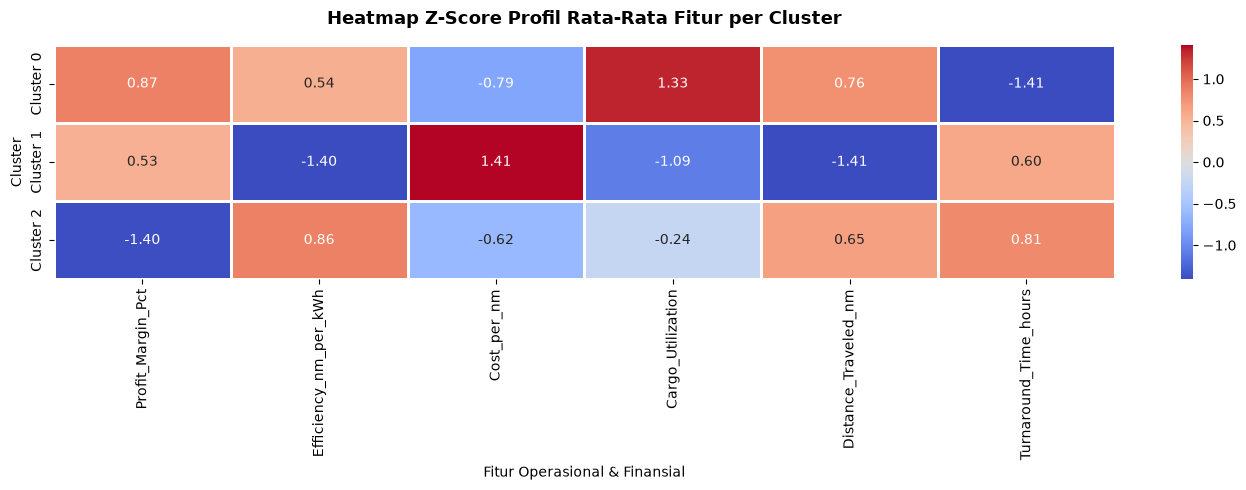

In [24]:
# Visualisasi Heatmap Normalisasi Profil Centroid Cluster
scaler_minmax = StandardScaler()
centroid_scaled = pd.DataFrame(
    scaler_minmax.fit_transform(cluster_summary),
    index=[f'Cluster {i}' for i in cluster_summary.index],
    columns=cluster_summary.columns
)

plt.figure(figsize=(14, 5))
sns.heatmap(centroid_scaled, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, linewidths=1)
plt.title('Heatmap Z-Score Profil Rata-Rata Fitur per Cluster', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Fitur Operasional & Finansial')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

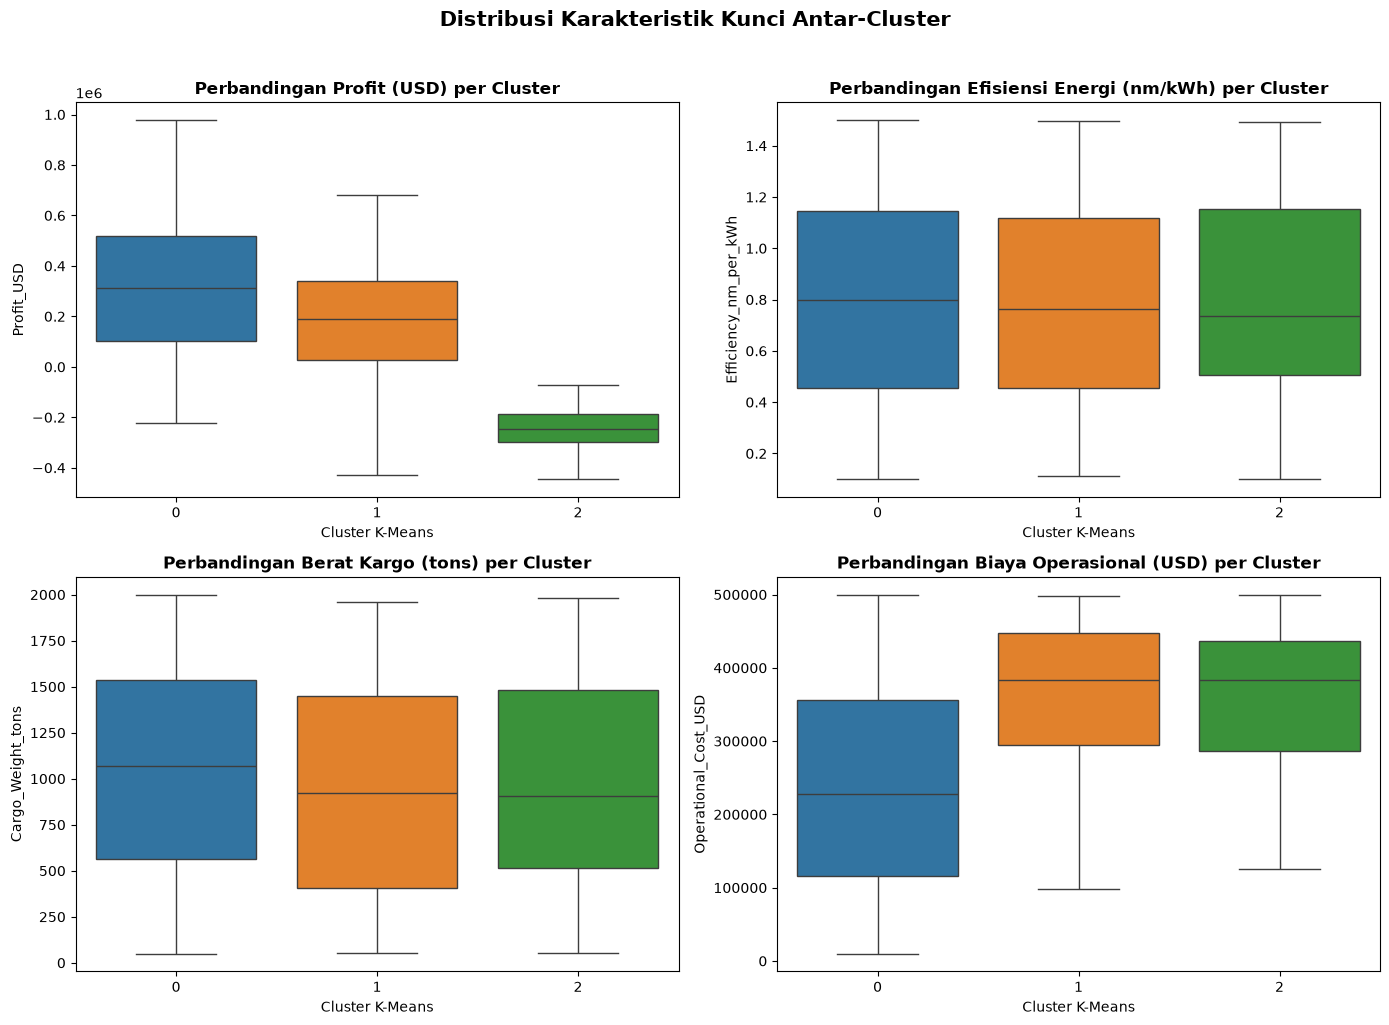

In [25]:
# Visualisasi Distribusi Fitur Finansial dan Operasional per Cluster
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df_clean, x='Cluster_KMeans', y='Profit_USD', palette='tab10', ax=axes[0, 0])
axes[0, 0].set_title('Perbandingan Profit (USD) per Cluster', fontweight='bold')
axes[0, 0].set_xlabel('Cluster K-Means')

sns.boxplot(data=df_clean, x='Cluster_KMeans', y='Efficiency_nm_per_kWh', palette='tab10', ax=axes[0, 1])
axes[0, 1].set_title('Perbandingan Efisiensi Energi (nm/kWh) per Cluster', fontweight='bold')
axes[0, 1].set_xlabel('Cluster K-Means')

sns.boxplot(data=df_clean, x='Cluster_KMeans', y='Cargo_Weight_tons', palette='tab10', ax=axes[1, 0])
axes[1, 0].set_title('Perbandingan Berat Kargo (tons) per Cluster', fontweight='bold')
axes[1, 0].set_xlabel('Cluster K-Means')

sns.boxplot(data=df_clean, x='Cluster_KMeans', y='Operational_Cost_USD', palette='tab10', ax=axes[1, 1])
axes[1, 1].set_title('Perbandingan Biaya Operasional (USD) per Cluster', fontweight='bold')
axes[1, 1].set_xlabel('Cluster K-Means')

plt.suptitle('Distribusi Karakteristik Kunci Antar-Cluster', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

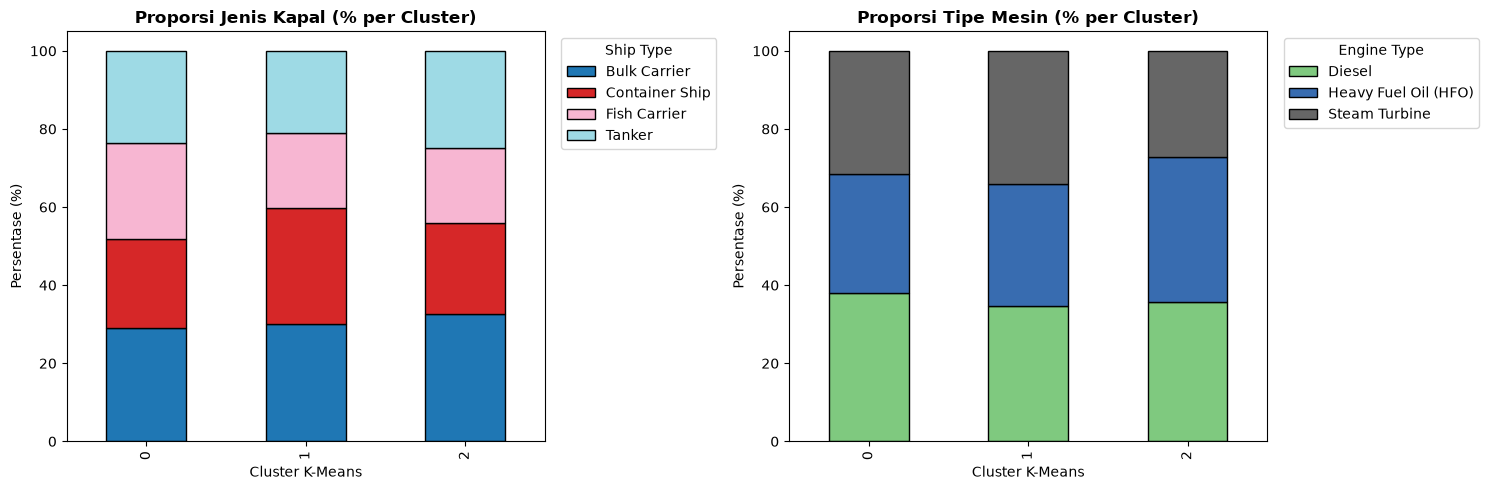

In [26]:
# 5.5 Distribusi Jenis Kapal & Mesin pada Setiap Cluster
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ct_ship = pd.crosstab(df_clean['Cluster_KMeans'], df_clean['Ship_Type'], normalize='index') * 100
ct_ship.plot(kind='bar', stacked=True, colormap='tab20', ax=axes[0], edgecolor='black')
axes[0].set_title('Proporsi Jenis Kapal (% per Cluster)', fontweight='bold')
axes[0].set_xlabel('Cluster K-Means')
axes[0].set_ylabel('Persentase (%)')
axes[0].legend(title='Ship Type', bbox_to_anchor=(1.02, 1), loc='upper left')

ct_engine = pd.crosstab(df_clean['Cluster_KMeans'], df_clean['Engine_Type'], normalize='index') * 100
ct_engine.plot(kind='bar', stacked=True, colormap='Accent', ax=axes[1], edgecolor='black')
axes[1].set_title('Proporsi Tipe Mesin (% per Cluster)', fontweight='bold')
axes[1].set_xlabel('Cluster K-Means')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(title='Engine Type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 6. Deployment (Model Export)
---

In [27]:
import os
import pickle

models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

cluster_names = {
    0: 'Cluster 0: Moderate Fleet',
    1: 'Cluster 1: High Efficiency & Profit',
    2: 'Cluster 2: Heavy Load & High Cost'
}

cluster_descriptions = {
    0: {
        'title': 'Cluster 0: Moderate Fleet',
        'summary': 'Kapal dengan kecepatan dan daya mesin tinggi namun utilisasi muatan kargo pada tingkat moderat (~67%).',
        'status': 'info'
    },
    1: {
        'title': 'Cluster 1: High Efficiency & Profit',
        'summary': 'Kapal dengan efisiensi energi tertinggi (~0.87 nm/kWh), konsumsi daya mesin hemat, dan margin profit stabil.',
        'status': 'success'
    },
    2: {
        'title': 'Cluster 2: Heavy Load & High Cost',
        'summary': 'Kapal dengan kapasitas muatan sangat tinggi (rata-rata muatan ~90%) dan pendapatan per pelayaran tertinggi.',
        'status': 'success'
    }
}

artifacts = {
    'kmeans_model': kmeans_model,
    'scaler': scaler,
    'pca': pca,
    'features': clustering_features,
    'cluster_names': cluster_names,
    'cluster_descriptions': cluster_descriptions,
    'optimal_k': OPTIMAL_K,
    'metrics': {
        'silhouette_score': float(silhouette_score(X_scaled, kmeans_labels)),
        'davies_bouldin_index': float(davies_bouldin_score(X_scaled, kmeans_labels)),
        'calinski_harabasz': float(calinski_harabasz_score(X_scaled, kmeans_labels))
    }
}

with open(os.path.join(models_dir, 'kmeans_ship_model.pkl'), 'wb') as f:
    pickle.dump(artifacts, f)

with open(os.path.join(models_dir, 'kmeans_model.pkl'), 'wb') as f:
    pickle.dump(kmeans_model, f)

with open(os.path.join(models_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(models_dir, 'pca.pkl'), 'wb') as f:
    pickle.dump(pca, f)

print("Seluruh model berhasil diekspor ke folder 'models/':")
for fname in os.listdir(models_dir):
    if fname.endswith('.pkl'):
        fpath = os.path.join(models_dir, fname)
        print(f"   - {fname} ({os.path.getsize(fpath)} bytes)")


Seluruh model berhasil diekspor ke folder 'models/':
   - scaler.pkl (623 bytes)
   - kmeans_model.pkl (11642 bytes)
   - pca.pkl (925 bytes)
   - kmeans_ship_model.pkl (13748 bytes)


---

Copyright © 2026 by Tim Pengembangan DGX, Universitas Gunadarma


https://www.hpc-hub.gunadarma.ac.id/